# Idea `xau-prior-atr-complete`

This notebook is a **live representation** of Python in `themis.ask`. Run All on the Themis (.venv) kernel. It does not reimplement ATR.

English: *On Gold, for the last month, how many times the ATR is completed from the previous day*

**Ask, not a trade.** Logic: `atr_path_days`, `atr_complete_table`, `atr_complete_rivals`. Families (`strategies/*`, fill, metrics) stay shared and unused here.

Unnamed keys (frozen in `ATR_COMPLETE_RIVALS`): ATR 14 vs 20; complete = daily range vs from-open. Window: last calendar month of loaded bars.


In [1]:
from pathlib import Path
import os

here = Path.cwd()
repo = here
while repo != repo.parent and not (repo / "docs" / "open-spec.md").exists():
    repo = repo.parent
os.environ["THEMIS_ROOT"] = str(repo)
os.chdir(repo)

from themis.data import load_from_spec
from themis.spec import load_spec
from themis.ask import (
    atr_path_days,
    atr_complete_rivals,
    plot_range_vs_prior_atr,
)

SPEC = repo / 'research/runs/20260829T025701Z-xau-atr-complete-atr14-range-bdc0a206/spec.yaml'
spec = load_spec(SPEC)
spec["id"], spec.get("measure"), spec.get("instrument")


('xau-atr-complete-atr14-range',
 'atr_complete',
 {'symbol': 'XAUUSDT',
  'venue': 'binance',
  'provider': 'binance',
  'timeframe': '4h',
  'timezone': 'UTC',
  'exchange': 'binanceusdm'})

## 1. Series

`themis.data` loads the frozen spec. Binance `XAUUSDT` perp, not COMEX.


In [2]:
series = load_from_spec(spec, root=repo, network=False)
ohlc = series.df
series.identity


{'provider': 'binance',
 'symbol': 'XAUUSDT',
 'exchange': 'binanceusdm',
 'timeframe': '4h',
 'source': 'csv',
 'row_count': 552,
 'actual_start': '2026-05-01 00:00:00+00:00',
 'actual_end': '2026-07-31 20:00:00+00:00',
 'not': 'not COMEX'}

## 2. Path frame (Python)

`atr_path_days` builds UTC daily OHLC, range, from-open, ATR, **prior_atr = atr.shift(1)**.


In [3]:
path = atr_path_days(ohlc, atr_n=14)
path[["open", "high", "low", "close", "day_range", "from_open", "atr", "prior_atr"]].tail(8)


,open,high,low,close,day_range,from_open,atr,prior_atr
ts,,,,,,,,
2026-07-24 00:00:00+00:00,4051.46,4086.81,4026.81,4063.19,60.00,35.35,65.691429,65.890714
2026-07-25 00:00:00+00:00,4063.18,4066.00,4057.85,4064.40,8.15,5.33,65.435000,65.691429
2026-07-26 00:00:00+00:00,4064.40,4100.00,4062.42,4098.38,37.58,35.60,65.083571,65.435000
2026-07-27 00:00:00+00:00,4098.39,4120.43,4069.59,4076.96,50.84,28.80,61.207143,65.083571
2026-07-28 00:00:00+00:00,4076.95,4077.69,4016.16,4030.04,61.53,60.79,57.045000,61.207143
2026-07-29 00:00:00+00:00,4030.04,4120.44,4003.11,4092.01,117.33,90.40,60.700714,57.045000
2026-07-30 00:00:00+00:00,4092.01,4126.64,4039.00,4111.46,87.64,53.01,60.561429,60.700714
2026-07-31 00:00:00+00:00,4111.47,4112.81,4029.47,4054.80,83.34,82.00,62.025714,60.561429


## 3. Rivals (Python catalog)

`atr_complete_rivals` applies `ATR_COMPLETE_RIVALS` and the last-calendar-month window.


In [4]:
summary, tables = atr_complete_rivals(ohlc)
summary


,n,n_days,n_complete,complete_rate,complete_rate_ci95,atr_n,complete_def,window_start,window_end,median_range_over_atr
0,31,31,15,0.4839,0.1759,14,day_range,2026-07-01 00:00:00+00:00,2026-07-31 00:00:00+00:00,0.9161
1,31,31,14,0.4516,0.1752,20,day_range,2026-07-01 00:00:00+00:00,2026-07-31 00:00:00+00:00,0.9131
2,31,31,10,0.3226,0.1646,14,from_open,2026-07-01 00:00:00+00:00,2026-07-31 00:00:00+00:00,0.7905
3,31,31,10,0.3226,0.1646,20,from_open,2026-07-01 00:00:00+00:00,2026-07-31 00:00:00+00:00,0.7857


## 4. One rival, day by day


In [7]:
july = tables[(14, "day_range")]
july[["open", "high", "low", "close", "prior_atr", "day_range", "from_open", "complete", "range_over_atr"]]


,open,high,low,close,prior_atr,day_range,from_open,complete,range_over_atr
ts,,,,,,,,,
2026-07-01 00:00:00+00:00,4007.73,4116.82,3962.75,4037.15,86.742143,154.07,109.09,True,1.776184
2026-07-02 00:00:00+00:00,4037.22,4145.99,4033.33,4129.09,86.120000,112.66,108.77,True,1.308175
2026-07-03 00:00:00+00:00,4129.08,4196.86,4126.00,4176.26,84.010714,70.86,67.78,False,0.843464
2026-07-04 00:00:00+00:00,4176.26,4179.85,4172.00,4179.49,83.657857,7.85,4.26,False,0.093835
2026-07-05 00:00:00+00:00,4179.49,4202.98,4175.50,4185.19,83.294286,27.48,23.49,False,0.329915
2026-07-06 00:00:00+00:00,4185.20,4204.41,4131.45,4159.44,82.849286,72.96,53.75,False,0.880635
2026-07-07 00:00:00+00:00,4159.44,4182.91,4093.34,4100.87,82.326429,89.57,66.10,True,1.087986
2026-07-08 00:00:00+00:00,4100.72,4135.90,4024.54,4078.36,80.307857,111.36,76.18,True,1.386664
2026-07-09 00:00:00+00:00,4078.37,4139.53,4056.95,4125.61,77.370000,82.58,61.16,True,1.067339


<Axes: title={'center': 'XAUUSDT daily range vs prior-day ATR(14) — last calendar month'}, xlabel='ts', ylabel='price points'>

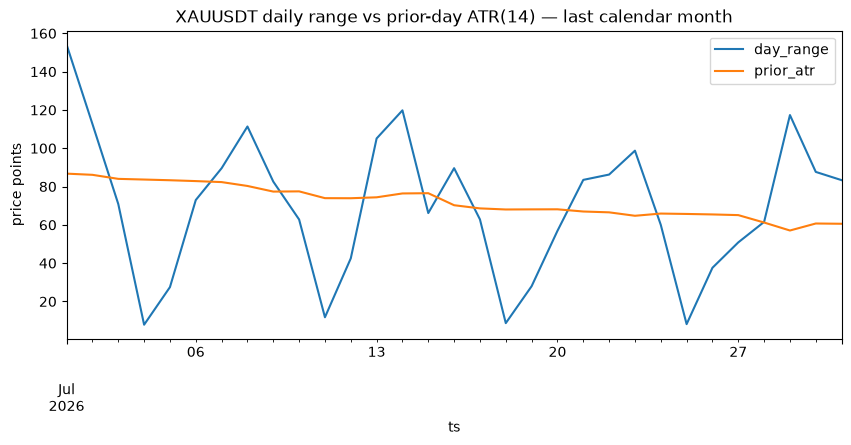

In [8]:
plot_range_vs_prior_atr(
    july,
    title="XAUUSDT daily range vs prior-day ATR(14) — last calendar month",
)


Chat quotes **run folders**. This notebook calls the same functions. If they disagree, the folder wins.

Do not multiply `complete_rate` by R. Screen is weak on n≈30.
